In [ ]:
%load_ext autoreload
%autoreload 2

import pickle
import ujson
import json
import sys
import os
from collections import Counter, defaultdict

import time
import pandas as pd
import numpy as np
import torch
import random
import faiss
import gzip
from tqdm import tqdm
from typing import Optional
import matplotlib.patches as mpatches

from IPython.display import HTML, display
from bioel.utils.umls_utils import UmlsMappings
from bioel.utils.bigbio_utils import CUIS_TO_REMAP, CUIS_TO_EXCLUDE, DATASET_NAMES, VALIDATION_DOCUMENT_IDS
from bioel.utils.bigbio_utils import load_bigbio_dataset, add_deabbreviations, dataset_to_documents, dataset_to_df, load_dataset_df, resolve_abbreviation, dataset_unique_tax_ids
from bioel.dataset import Dataset
from bioel.utils.solve_abbreviation.solve_abbreviations import create_abbrev
from bioel.ontology import BiomedicalOntology
from bioel.models.arboel.biencoder.data.data_utils import process_ontology
from bioel.evaluate import Evaluate, min_hit_index


import matplotlib.pyplot as plt
from utils_functions import *

/nethome/cye73/conda_envs/bioel/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
##### ----------------- Load medic ----------------- #####

# dataset_name = 'ncbi_disease'
# medic_dict = {"name" : "medic",
#             "filepath" : "/mitchell/entity-linking/kbs/medic.tsv"}

# ontology = BiomedicalOntology.load_medic(**medic_dict)

# ##### ----------------- Load entrez ----------------- #####

dataset_name = "nlm_gene" # "gnormplus" 

entrez_dict = {"name" : "entrez",
             "filepath" : "/mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv",
             "dataset" : f"{dataset_name}",}
ontology = BiomedicalOntology.load_entrez(**entrez_dict)

# ##### ----------------- Load MESH ----------------- #####

# dataset_name = "nlmchem"
# mesh_dict = {"name" : "mesh",
#              "filepath" : "/mitchell/entity-linking/2017AA/META/"}
# ontology = BiomedicalOntology.load_mesh(**mesh_dict)

# ##### ----------------- Load UMLS (st21pv subset) ----------------- #####

# dataset_name = "medmentions_st21pv"
# umls_dict_st21pv = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
#     "path_st21pv_cui": "/home2/cye73/data_test2/arboel/medmentions_st21pv/umls_cuis_st21pv.json",
# }
# ontology = BiomedicalOntology.load_umls(**umls_dict_st21pv)

# ##### ----------------- Load UMLS (full) ----------------- #####

# dataset_name = "medmentions_full"
# umls_dict = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
# }
# ontology = BiomedicalOntology.load_umls(**umls_dict)

[2025-02-07 18:41:20] [ontology.py] [INFO] Reading entrez from /mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv
[2025-02-07 18:43:20] [bigbio_utils.py] [INFO] Number of unique tax_ids in nlm_gene : 26
100%|██████████| 704575/704575 [00:03<00:00, 203269.05it/s]


In [3]:
ontology.entities

{'NCBIGene:801477': BiomedicalEntity(cui='NCBIGene:801477', name='rrnL2a', types='rRNA', aliases='', definition='L2a ribosomal RNA', equivalant_cuis=None, taxonomy=3055, metadata=''),
 'NCBIGene:801478': BiomedicalEntity(cui='NCBIGene:801478', name='rrnL2b', types='rRNA', aliases='', definition='L2b ribosomal RNA', equivalant_cuis=None, taxonomy=3055, metadata=''),
 'NCBIGene:801480': BiomedicalEntity(cui='NCBIGene:801480', name='rrnL6', types='rRNA', aliases='', definition='L6 ribosomal RNA', equivalant_cuis=None, taxonomy=3055, metadata=''),
 'NCBIGene:801481': BiomedicalEntity(cui='NCBIGene:801481', name='rrnL7', types='rRNA', aliases='', definition='L7 ribosomal RNA', equivalant_cuis=None, taxonomy=3055, metadata=''),
 'NCBIGene:801482': BiomedicalEntity(cui='NCBIGene:801482', name='rrnL4', types='rRNA', aliases='', definition='L4 ribosomal RNA', equivalant_cuis=None, taxonomy=3055, metadata=''),
 'NCBIGene:801483': BiomedicalEntity(cui='NCBIGene:801483', name='rrnS3', types='rRNA'

In [4]:
import pandas as pd

def convert_ontology_to_df(ontology_dict):
    data = []
    for cui, entity in ontology_dict.items():
        aliases = []
        if entity.aliases:
            if isinstance(entity.aliases, list):
                # If aliases is already a list, filter out None and extend aliases
                aliases.extend([alias.strip() for alias in entity.aliases if alias])
            elif isinstance(entity.aliases, str):
                # If aliases is a string, split by '|' and add to aliases
                aliases.extend([alias.strip() for alias in entity.aliases.split('|') if alias])
        data.append({
            "CUI": cui,
            "Name": entity.name,
            "Types": entity.types,
            "Aliases": aliases if aliases else None,
            "has_aliases": True if aliases else False,
            "had_definition": True if entity.definition else False,
            "metadata": entity.metadata if entity.metadata else None,
        })
    
    df = pd.DataFrame(data)
    return df

In [5]:
df = convert_ontology_to_df(ontology.entities)
df 

,CUI,Name,Types,Aliases,has_aliases,had_definition,metadata
0,NCBIGene:801477,rrnL2a,rRNA,None,False,True,None
1,NCBIGene:801478,rrnL2b,rRNA,None,False,True,None
2,NCBIGene:801480,rrnL6,rRNA,None,False,True,None
3,NCBIGene:801481,rrnL7,rRNA,None,False,True,None
4,NCBIGene:801482,rrnL4,rRNA,None,False,True,None
...,...,...,...,...,...,...,...
704570,NCBIGene:2777492,Sv prime,other,None,False,False,None
704571,NCBIGene:2777493,parB,protein-coding,None,False,True,None
704572,NCBIGene:2777494,parA,protein-coding,None,False,True,None
704573,NCBIGene:2777495,c4,miscRNA,None,False,True,None


dataset : ncbi_disease, model : sapbert
dataset : ncbi_disease, model : arboel
dataset : medmentions_st21pv, model : sapbert
dataset : medmentions_st21pv, model : arboel
dataset : gnormplus, model : sapbert
dataset : gnormplus, model : arboel
dataset : nlmchem, model : sapbert
dataset : nlmchem, model : arboel
dataset : nlm_gene, model : sapbert
dataset : nlm_gene, model : arboel


  0%|          | 0/1 [00:00<?, ?it/s]

Eval Strategy: basic
ncbi_disease


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

medmentions_st21pv


...

nlmchem


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

nlm_gene


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

eval_strategy='basic'
dataset_to_pretty_name.get(name, name)='NCBI-Disease'
dataset_to_pretty_name.get(name, name)='MM-ST21PV'
dataset_to_pretty_name.get(name, name)='GNormPlus'
dataset_to_pretty_name.get(name, name)='NLM-Chem'
dataset_to_pretty_name.get(name, name)='NLM-Gene'


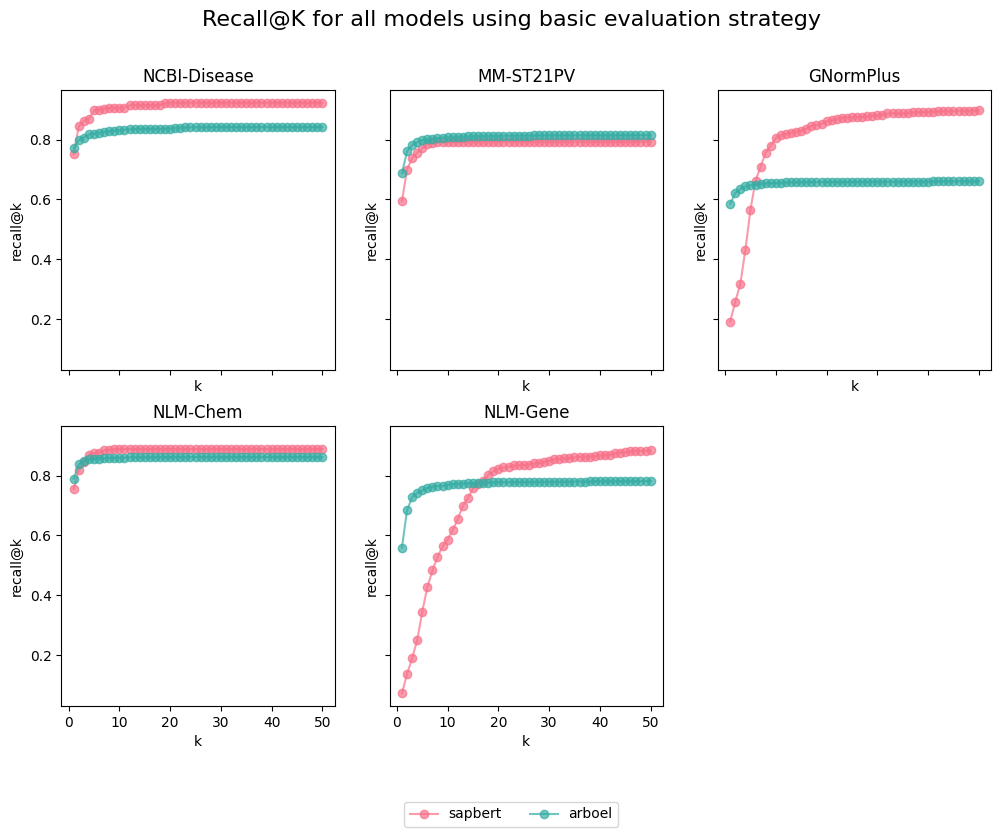

100%|██████████| 1/1 [00:00<00:00,  1.72it/s]


In [6]:
dataset_names = [
    "ncbi_disease",
    "medmentions_st21pv",
    "gnormplus",
    "nlmchem",
    "nlm_gene",
]

model_names = [
    "sapbert",
    "arboel",
]
path_to_result = {
    "ncbi_disease": {
        "arboel": "candidates/ncbi_disease/arboel_ncbi_disease.json",
        "sapbert": "candidates/ncbi_disease/sapbert_ncbi_disease.json",
    },
    "nlmchem" : {
        "arboel": "candidates/nlmchem/arboel_nlmchem.json",
        "sapbert": "candidates/nlmchem/sapbert_nlmchem.json",
    },
    "nlm_gene" : {
        "arboel": "candidates/nlm_gene/arboel_nlm_gene.json",
        "sapbert": "candidates/nlm_gene/sapbert_nlm_gene.json",
    },
    "gnormplus" : {
        "arboel": "candidates/gnormplus/arboel_gnormplus.json",
        "sapbert": "candidates/gnormplus/sapbert_gnormplus.json",
    },
    "medmentions_st21pv": {
        "arboel": "candidates/medmentions_st21pv/arboel_medmentions_st21pv.json",
        "sapbert": "candidates/medmentions_st21pv/sapbert_medmentions_st21pv.json",
    },
}


eval_strategies=["basic"]
abbreviations_path = "/home2/cye73/data_test/abbreviations.json"

evaluator = Evaluate(dataset_names=dataset_names, 
                     model_names=model_names, 
                     path_to_result=path_to_result, 
                     abbreviations_path=abbreviations_path,
                     eval_strategies=eval_strategies,
                     max_k = 50)

evaluator.load_results()
evaluator.process_datasets()
evaluator.evaluate()
evaluator.plot_results(eval_strategies=eval_strategies)

In [7]:
filtered_results = evaluator.full_results['basic'][dataset_name]

evaluator.detailed_results(k=20)

for dataset in dataset_names:
    for model in model_names:
        CG = evaluator.detailed_results_analysis['basic'][dataset][model]['failure_stage_CG']
        NED = evaluator.detailed_results_analysis['basic'][dataset][model]['failure_stage_NED']
        print(dataset, model)
        print("CG :", CG)
        print("NED :", NED)

Processing sapbert_resolve_abbrev
Processing arboel_resolve_abbrev
Processing sapbert_resolve_abbrev
Processing arboel_resolve_abbrev
Processing sapbert_resolve_abbrev
Processing arboel_resolve_abbrev
Processing sapbert_resolve_abbrev
Processing arboel_resolve_abbrev
Processing sapbert_resolve_abbrev
Processing arboel_resolve_abbrev
ncbi_disease sapbert
CG : 0.3067226890756303
NED : 0.6932773109243697
ncbi_disease arboel
CG : 0.6954545454545454
NED : 0.30454545454545456
medmentions_st21pv sapbert
CG : 0.5079783969559347
NED : 0.4920216030440653
medmentions_st21pv arboel
CG : 0.5977203889685956
NED : 0.4022796110314044
gnormplus sapbert
CG : 0.16660268714011517
NED : 0.8333973128598848
gnormplus arboel
CG : 0.8227374719521316
NED : 0.17726252804786835
nlmchem sapbert
CG : 0.45126227208976155
NED : 0.5487377279102384
nlmchem arboel
CG : 0.6542553191489362
NED : 0.34574468085106386
nlm_gene sapbert
CG : 0.18562401263823064
NED : 0.8143759873617693
nlm_gene arboel
CG : 0.5033277870216306
N

In [8]:
number_candidates = 20
results = evaluator.full_results["basic"][f"{dataset_name}"]

# Base columns common to all models
base_cols = ['document_id', 'offsets', 'text', 'deabbreviated_text', 'db_ids', 'mention_id', 'joined_offsets']

model_cols = ['sapbert_resolve_abbrev', 'sapbert_resolve_abbrev_min_hit_index']
rename_map = {
    'sapbert_resolve_abbrev': 'sapbert_candidates',
    'sapbert_resolve_abbrev_min_hit_index': 'sapbert_hit_index'
}
cols = base_cols + model_cols
filtered_results_sapbert = results[cols].rename(columns=rename_map)
filtered_results_sapbert = filtered_results_sapbert[filtered_results_sapbert[f'sapbert_hit_index'] < number_candidates]


model_cols = ['arboel_resolve_abbrev', 'arboel_resolve_abbrev_min_hit_index']
rename_map = {
    'arboel_resolve_abbrev': 'arboel_candidates',
    'arboel_resolve_abbrev_min_hit_index': 'arboel_hit_index'
}
cols = base_cols + model_cols
filtered_results_arboel = results[cols].rename(columns=rename_map)
filtered_results_arboel = filtered_results_arboel[filtered_results_arboel[f'arboel_hit_index'] < number_candidates]

# print(len(filtered_results_sapbert)/len(results))
# print(len(results))

# Evaluate data slices

In [9]:
def cui_to_alias(input_dict):
    """
    Creates a dictionary with "cui" as the key and "synonyms" as a list of unique names (name, aliases).
    -------------
    input_dict (dict): A dictionary where values are BiomedicalEntity objects.
    """
    result = {}
    for cui, entity in input_dict.items():
        # Extract the primary name
        synonyms = [entity.name]

        # Handle aliases
        if entity.aliases:
            if isinstance(entity.aliases, list):
                # If aliases is already a list, filter out None and extend synonyms
                synonyms.extend([alias.strip() for alias in entity.aliases if alias])
            elif isinstance(entity.aliases, str):
                # If aliases is a string, split by '|' and add to synonyms
                synonyms.extend([alias.strip() for alias in entity.aliases.split('|') if alias])

        # Remove duplicates while preserving order
        unique_aliases = list(dict.fromkeys(synonyms))

        # Add to result
        result[cui] = unique_aliases

        # Add to result for equivalent CUIs
        if entity.equivalant_cuis:
            for equiv_cui in entity.equivalant_cuis:
                if equiv_cui not in result:
                    result[equiv_cui] = unique_aliases
                else:
                    # Merge synonyms while preserving order
                    result[equiv_cui] = list(dict.fromkeys(result[equiv_cui] + unique_aliases))
    return result

def cui_to_def(input_dict):
    """
    Creates a dictionary with "cui" as the key and "definition" as value.
    -------------
    input_dict (dict): A dictionary where values are BiomedicalEntity objects.
    """
    result = {}
    for cui, entity in input_dict.items():

        # Handle aliases
        if not entity.definition:
            continue
        else:
            result[cui] = entity.definition

        # Add to result for equivalent CUIs
        if entity.equivalant_cuis:
            for equiv_cui in entity.equivalant_cuis:
                if equiv_cui not in result:
                    result[equiv_cui] = entity.definition
    return result

def check_match(candidate, item_list):
    if candidate in item_list:
        return True
    else:
        return False
    
def check_alias_match(mention, gold_cuis, alias2cui):
    if mention in alias2cui:
        cuis = alias2cui[mention]
        if any(c in cuis for c in gold_cuis):
            return True
    return False

def wrong_alias_match(mention, gold_cuis, alias2cui):
    if mention in alias2cui:
        cuis = alias2cui[mention]
        if any(c not in gold_cuis for c in cuis):
            return True
    return False


def compute_correct_proportion(df, slice_column, model_columns, coeff):
    """
    Computes the proportion of correct answers (hit_index == 0) for each slice of data.

    Parameters:
    - df: DataFrame containing the data
    - slice_column: The column that defines the slice (e.g., "alias_match")
    - model_columns: List of model columns to check for correctness (e.g., ["arboel", "sapbert"])

    Returns:
    - DataFrame with proportions of correct answers per slice
    """
    results = []
    
    # Get unique slices
    unique_slices = df[slice_column].unique()
    
    for slice_value in unique_slices:
        slice_df = df[df[slice_column] == slice_value]
        slice_size = len(slice_df)
        
        # Compute correctness proportion for each model
        proportions = {model: round((slice_df[model] == 0).mean()* coeff, 3) for model in model_columns}
        proportions["slice_value"] = slice_value
        proportions["slice_size"] = slice_size  # Number of examples in the slice
        
        results.append(proportions)
    
    results_df = pd.DataFrame(results)
    return results_df


In [10]:
llm = "GPT4o"
# llm = "Qwen"
llms = {'Qwen': 'Qwen2.5-7B-Instruct', 
        'Mistral': 'Mistral-Nemo-Instruct-2407',
        'Llama': "Meta-Llama-3.1-8B-Instruct",
        "GPT4o": 'gpt-4o-2024-08-06'}

with open(
    f"results/{dataset_name}/sapbert/accuracy/{llms[llm]}_k=3_cands=20_recall=False5_true_results.json", "r"
) as f:
    results_sapbert = json.load(f) 
with open(
    f"results/{dataset_name}/arboel/accuracy/{llms[llm]}_k=3_cands=20_recall=False5_true_results.json", "r"
) as f:
    results_arboel = json.load(f)


In [11]:
mentions_sapbert = set(results_sapbert.keys())
mentions_arboel = set(results_arboel.keys())


In [12]:
path_to_abbrev = "/home2/cye73/data_test2/abbreviations.json"
dataset = load_bigbio_dataset(dataset_name)
dataset = add_deabbreviations(dataset, path_to_abbrev)
dataset_df = dataset_to_df(dataset)
# test_df = dataset_df[dataset_df['split'] == 'test']
test_df = evaluator.full_results['basic'][dataset_name]
train_df = dataset_df[dataset_df['split'] == 'train']

In [13]:
mention_test = set(test_df['mention_id'].values)
mention_eval = set(evaluator.full_results['basic'][dataset_name]['mention_id'].values)

In [14]:
len(mention_test), len(mention_eval)
mentions = mention_test.intersection(mention_eval)


In [15]:
columns = ["document_id", "offsets", "text", "type", "db_ids", "split", "deabbreviated_text", "mention_id", "joined_offsets"]
sapbert_df = test_df.copy()[columns]
arboel_df = test_df.copy()[columns]

In [16]:
for index, row in test_df.iterrows():
    mention_id = row['mention_id'] 
    if mention_id in results_sapbert:
        sapbert_df.loc[index, f'pred_sapbert_{llm}'] = results_sapbert[mention_id]['predicted']
    if mention_id in results_arboel:
        arboel_df.loc[index, f'pred_arboel_{llm}'] = results_arboel[mention_id]['predicted']
        
sapbert_df = sapbert_df[sapbert_df['mention_id'].isin(mentions_sapbert)]
arboel_df = arboel_df[arboel_df['mention_id'].isin(mentions_arboel)]

In [17]:
mention2gold_arboel = {}
mention2gold_sapbert = {}

for idx, row in filtered_results_sapbert.iterrows():
    mention2gold_sapbert[row['mention_id']] = row['db_ids']

for idx, row in filtered_results_arboel.iterrows():
    mention2gold_arboel[row['mention_id']] = row['db_ids']
    

In [18]:
print(len(test_df), len(filtered_results_arboel), len(filtered_results_sapbert))
score_arboel, match_arboel, nb_cands_arboel, errors_arboel = scoring(results = results_arboel, mention2gold = mention2gold_arboel)
score_sapbert, match_sapbert, nb_cands_sapbert, errors_sapbert = scoring(results = results_sapbert, mention2gold = mention2gold_sapbert)
print("Result of arboel:", score_arboel * len(filtered_results_arboel) / len(test_df))
print("Result of sapbert:", score_sapbert * len(filtered_results_sapbert) / len(test_df))

2729 2123 2248
Result of arboel: 0.5430560644924881
Result of sapbert: 0.5034218602633183


In [19]:
# score_arboel, match_arboel, nb_cands_arboel, errors_arboel

In [20]:
sapbert_df[f'sapbert_{llm}'] = sapbert_df.apply(
lambda row: 0 if (
    # isinstance(row["db_ids"], list) and row["db_ids"] and  # Ensure db_ids is a list and not empty
    isinstance(row[f'pred_sapbert_{llm}'], str) and  # Ensure prediction is a string
    row[f'pred_sapbert_{llm}'] in row["db_ids"]  # Compare to first element of the list
) else 1000000,
axis=1)

arboel_df[f'arboel_{llm}'] = arboel_df.apply(
lambda row: 0 if (
    # isinstance(row["db_ids"], list) and row["db_ids"] and  # Ensure db_ids is a list and not empty
    isinstance(row[f'pred_arboel_{llm}'], str) and  # Ensure prediction is a string
    row[f'pred_arboel_{llm}'] in row["db_ids"]  # Compare to first element of the list
) else 1000000,
axis=1)

In [21]:
cui2alias = cui_to_alias(ontology.entities)

corpus_aliases = []
for cui, aliases in cui2alias.items():
    for alias in aliases:
        corpus_aliases.append(alias.lower())
# print(len(corpus_aliases))

alias2cui = defaultdict(list)
for cui, aliases in cui2alias.items():
    for alias in aliases:
        alias2cui[alias.lower()].append(cui)
# alias2cui

cui2def = cui_to_def(ontology.entities)

In [22]:

train_entities = set([])
for id_list in train_df['db_ids']:
    train_entities.update(set(id_list))

train_mentions = defaultdict(int)
for mention in train_df['text']:
    train_mentions[mention] += 1

train_pairs = set([])
for mention, db_ids in train_df[['text', 'db_ids']].values:
    for cui in db_ids:
        train_pairs.add((mention, cui))
# train_mentions

In [23]:
test_df = test_df.rename(columns={'arboel_resolve_abbrev_min_hit_index' : 'arboel', 'sapbert_resolve_abbrev_min_hit_index' : 'sapbert'})

# mention matches with one of the aliases of gold cui
test_df['has_alias_match'] = test_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
# mention matches with no alias of gold cui
test_df['no_alias_match'] = ~test_df['has_alias_match']
# mention matches with one of the aliases of an incorrect cui
test_df['wrong_alias_match'] = test_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
# mention matches with one of the mention from the training set
test_df['train_text_match'] = test_df['text'].map(lambda x: x in train_mentions)
# mention matches with 1 to 5 text mentions from the training set 
test_df['train_text_match<=5'] = test_df['text'].map(lambda x: 1 < train_mentions[x] <= 5)
# gold cui of mention also appears in the training set
test_df['train_entity_match'] = test_df['db_ids'].map(lambda x: any(y in train_entities for y in x))
# mention matches with one of the mention from the training set and they share the same gold cui
test_df['perfect_train_match'] = test_df[['text', 'db_ids']].apply(lambda x: any((x[0], cui) in train_pairs for cui in x[1]), axis=1)
# gold cui of the mention has only one alias
test_df['1_alias'] = test_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x) == 1)
# gold cui of the mention has 1 to 5 aliases
test_df['num_aliases<=5'] = test_df['db_ids'].map(lambda x: 1 < max(len(cui2alias.get(cui, [])) for cui in x) <= 5)
test_df['num_aliases'] = test_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x))
# gold cui doesn't have definition
test_df['no_def'] = test_df['db_ids'].map(lambda x: max(not cui2def.get(cui, 0) for cui in x) == 1)
# gold cui of the mention doesn't appear in the training set
test_df['zero_shot'] = ~test_df['train_entity_match']

/tmp/ipykernel_1341553/1452516215.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_df['has_alias_match'] = test_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/1452516215.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_df['wrong_alias_match'] = test_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/1452516215.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataF

In [24]:
sapbert_df['has_alias_match'] = sapbert_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
sapbert_df['no_alias_match'] = ~sapbert_df['has_alias_match']
sapbert_df['wrong_alias_match'] = sapbert_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
sapbert_df['train_text_match'] = sapbert_df['text'].map(lambda x: x in train_mentions)
sapbert_df['train_text_match<=5'] = sapbert_df['text'].map(lambda x: 1 < train_mentions[x] <= 5)
sapbert_df['train_entity_match'] = sapbert_df['db_ids'].map(lambda x: any(y in train_entities for y in x))
sapbert_df['perfect_train_match'] = sapbert_df[['text', 'db_ids']].apply(lambda x: any((x[0], cui) in train_pairs for cui in x[1]), axis=1)
sapbert_df['1_alias'] = sapbert_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x) == 1)
sapbert_df['num_aliases<=5'] = sapbert_df['db_ids'].map(lambda x: 1 < max(len(cui2alias.get(cui, [])) for cui in x) <= 5)
sapbert_df['num_aliases'] = sapbert_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x))
sapbert_df['no_def'] = sapbert_df['db_ids'].map(lambda x: max(not cui2def.get(cui, 0) for cui in x) == 1)
sapbert_df['zero_shot'] = ~sapbert_df['train_entity_match']

/tmp/ipykernel_1341553/754333375.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sapbert_df['has_alias_match'] = sapbert_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/754333375.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sapbert_df['wrong_alias_match'] = sapbert_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/754333375.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wi

In [25]:
arboel_df['has_alias_match'] = arboel_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
arboel_df['no_alias_match'] = ~arboel_df['has_alias_match']
arboel_df['wrong_alias_match'] = arboel_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
arboel_df['train_text_match'] = arboel_df['text'].map(lambda x: x in train_mentions)
arboel_df['train_text_match<=5'] = arboel_df['text'].map(lambda x: 1 < train_mentions[x] <= 5)
arboel_df['train_entity_match'] = arboel_df['db_ids'].map(lambda x: any(y in train_entities for y in x))
arboel_df['perfect_train_match'] = arboel_df[['text', 'db_ids']].apply(lambda x: any((x[0], cui) in train_pairs for cui in x[1]), axis=1)
arboel_df['1_alias'] = arboel_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x) == 1)
arboel_df['num_aliases<=5'] = arboel_df['db_ids'].map(lambda x: 1 < max(len(cui2alias.get(cui, [])) for cui in x) <= 5)
arboel_df['num_aliases'] = arboel_df['db_ids'].map(lambda x: max(len(cui2alias.get(cui, [])) for cui in x))
arboel_df['no_def'] = arboel_df['db_ids'].map(lambda x: max(not cui2def.get(cui, 0) for cui in x) == 1)
arboel_df['zero_shot'] = ~arboel_df['train_entity_match']

/tmp/ipykernel_1341553/4068593036.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arboel_df['has_alias_match'] = arboel_df[['text','db_ids']].apply(lambda x: check_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/4068593036.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arboel_df['wrong_alias_match'] = arboel_df[['text','db_ids']].apply(lambda x: wrong_alias_match(x[0], x[1], alias2cui), axis=1)
/tmp/ipykernel_1341553/4068593036.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wit

In [26]:
# slices to evaluate
data_slices = [
   'perfect_train_match', 
#   'has_alias_match', 
   'no_alias_match', 
   'wrong_alias_match', 
#   'train_text_match', 
#    'train_text_match<=5', 
#    'train_entity_match', 
#    '1_alias', 
   'num_aliases<=5',
#   'no_def',
   'zero_shot']

# print("RESULTS for arboel and sapbert without LLMs:")
# for data_slice in data_slices:
#    res = compute_correct_proportion(test_df, data_slice, 
#                                     model_columns = ["arboel", "sapbert"],
#                                     coeff = 1)
#    print(f"{data_slice}:")
#    display(res)

# print(f'RESULTS for arboel with {llm}:')
# for data_slice in data_slices:
#    res = compute_correct_proportion(arboel_df, data_slice, 
#                                     model_columns = [f"arboel_{llm}"],
#                                     coeff = len(filtered_results_arboel) / len(test_df))
#    print(f"{data_slice}:")
#    display(res)

print(f'RESULTS for sapbert with {llm}:')
for data_slice in data_slices:
   res = compute_correct_proportion(sapbert_df, data_slice, 
                                    model_columns = [f"sapbert_{llm}"],
                                    coeff = len(filtered_results_sapbert) / len(test_df))
   print(f"{data_slice}:")
   display(res)

RESULTS for sapbert with GPT4o:
perfect_train_match:


,sapbert_GPT4o,slice_value,slice_size
0,0.477,False,1289
1,0.534,True,835


no_alias_match:


,sapbert_GPT4o,slice_value,slice_size
0,0.494,True,2057
1,0.676,False,67


wrong_alias_match:


,sapbert_GPT4o,slice_value,slice_size
0,0.499,False,2039
1,0.504,True,85


num_aliases<=5:


,sapbert_GPT4o,slice_value,slice_size
0,0.419,True,1178
1,0.600,False,946


zero_shot:


,sapbert_GPT4o,slice_value,slice_size
0,0.524,False,1247
1,0.465,True,877


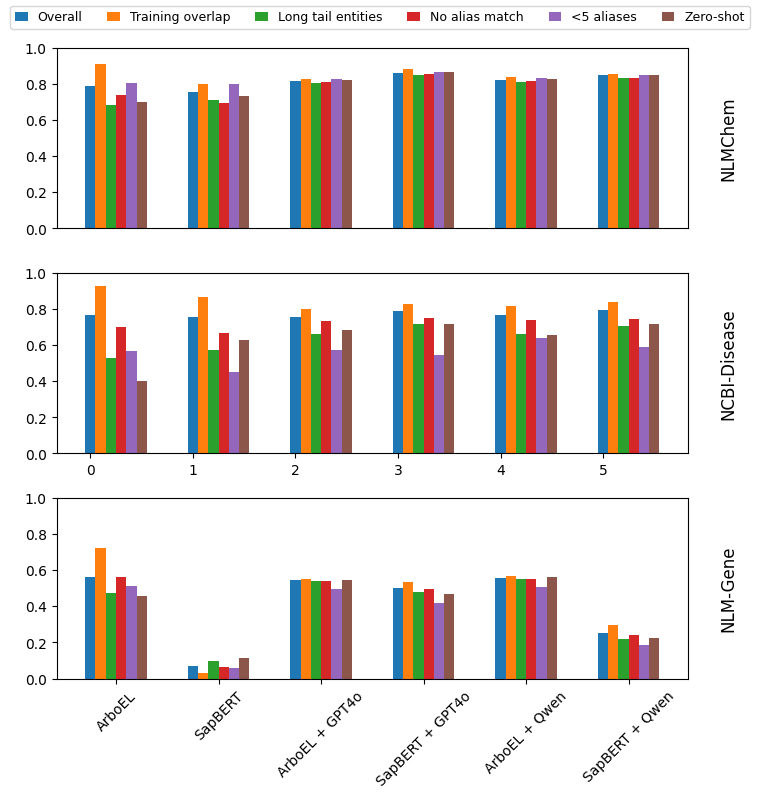

In [27]:
import matplotlib.patches as mpatches
categories = ["ArboEL", "SapBERT", "ArboEL + GPT4o", "SapBERT + GPT4o", "ArboEL + Qwen", "SapBERT + Qwen"]
metrics = [
    "Overall",
    "Training overlap",  # This metric will be ignored with "#"
    "Long tail entities",
    "No alias match",
    "# Wrong match",
    "<5 aliases",
    "Zero-shot"
]

# Corresponding data: each column corresponds to the same position as in the metrics list
data_nlm_gene = np.array([
    [0.559, 0.721, 0.473, 0.560, 0.463, 0.513, 0.455],  # ArboEL
    [0.072, 0.029, 0.095, 0.063, 0.074, 0.061, 0.115],  # SapBERT
    [0.543, 0.551, 0.538, 0.541, 0.496, 0.497, 0.544],  # ArboEL + GPT4o
    [0.501, 0.534, 0.477, 0.494, 0.504, 0.419, 0.465],  # SapBERT + GPT4o
    [0.556, 0.567, 0.548, 0.553, 0.561, 0.509, 0.559],  # ArboEL + Qwen
    [0.251, 0.295, 0.217, 0.242, 0.204, 0.185, 0.227],  # SapBERT + Qwen
])

data_gnormplus = np.array([
    [0.585, 0.985, 0.558, 0.576, 0.675, 0.587, 0.546],  # ArboEL
    [0.191, 0.059, 0.200, 0.190, 0.119, 0.221, 0.201],  # SapBERT
    [0.611, 0.652, 0.615, 0.617, 0.620, 0.614, 0.613],  # ArboEL + GPT4o
    [0.738, 0.857, 0.735, 0.740, 0.793, 0.731, 0.729],  # SapBERT + GPT4o
    [0.611, 0.636, 0.587, 0.587, 0.617, 0.597, 0.588],  # ArboEL + Qwen
    [0.365, 0.252, 0.362, 0.348, 0.388, 0.352, 0.350],  # SapBERT + Qwen
])

data_ncbi_disease = np.array([
    [0.766, 0.927, 0.527, 0.697, 0.941, 0.568, 0.400],  # ArboEL
    [0.752, 0.867, 0.572, 0.664, 0.914, 0.452, 0.630],  # SapBERT
    [0.752, 0.799, 0.662, 0.734, 0.792, 0.572, 0.682],  # ArboEL + GPT4o
    [0.790, 0.827, 0.718, 0.750, 0.899, 0.542, 0.717],  # SapBERT + GPT4o
    [0.767, 0.815, 0.662, 0.738, 0.797, 0.636, 0.656],  # ArboEL + Qwen
    [0.791, 0.837, 0.703, 0.743, 0.892, 0.589, 0.717],  # SapBERT + Qwen
])

data_nlmchem = np.array([
    [0.787, 0.908, 0.684, 0.738, 0.256, 0.806, 0.697],  # ArboEL
    [0.752, 0.800, 0.711, 0.694, 0.178, 0.796, 0.734],  # SapBERT
    [0.815, 0.828, 0.805, 0.811, 0.394, 0.827, 0.818],  # ArboEL + GPT4o
    [0.859, 0.879, 0.847, 0.856, 0.212, 0.867, 0.862],  # SapBERT + GPT4o
    [0.821, 0.838, 0.807, 0.813, 0.300, 0.830, 0.826],  # ArboEL + Qwen 
    [0.849, 0.856, 0.831, 0.832, 0.185, 0.850, 0.847],  # SapBERT + Qwen 
])


# Filter metrics and data to ignore those that are commented (i.e., strings starting with "#")
active_indices = [i for i, metric in enumerate(metrics) if not metric.strip().startswith("#")]
active_metrics = [metrics[i] for i in active_indices]
filtered_data_gnormplus = data_gnormplus[:, active_indices]
filtered_data_nlmchem = data_nlmchem[:, active_indices]
filtered_data_ncbi_disease = data_ncbi_disease[:, active_indices]
filtered_data_nlm_gene = data_nlm_gene[:, active_indices]

# Create a figure with 3 subplots (3 rows, 1 column)
fig, (ax2, ax3, ax4) = plt.subplots(3, 1, figsize=(7.4, 8))

# Common plotting parameters
x = np.arange(len(categories))
width = 0.10  # Width of each bar

# # -------------------------
# # First subplot: Bar Plot for GNormPlus
# # -------------------------
# for i, metric in enumerate(active_metrics):
#     ax1.bar(x + i * width, filtered_data_gnormplus[:, i], width, label=metric)
# # ax1.set_xlabel('GNormPlus')
# ax1.text(1.05, 0.5, 'GNormPlus', transform=ax1.transAxes, rotation=90, fontsize=12, va='center')
# ax1.set_xticks([])  # Remove tick marks
# # ax1.set_xticklabels([])  # Remove tick labels
# # ax1.set_ylabel('Proportion')
# # ax1.set_xticks(x + width * (len(active_metrics) - 1) / 2)
# # ax1.set_xticklabels(categories, rotation=45)
# ax1.set_ylim(0, 1)

# -------------------------
# Second subplot: Bar Plot for NLMCHEM
# -------------------------
for i, metric in enumerate(active_metrics):
    ax2.bar(x + i * width, filtered_data_nlmchem[:, i], width, label=metric)
# ax2.set_xlabel('NLMChem')
ax2.text(1.05, 0.5, 'NLMChem', transform=ax2.transAxes, rotation=90, fontsize=12, va='center')
ax2.set_xticks([])  # Remove tick marks
ax2.set_ylim(0, 1)

# -------------------------
# Third subplot: Bar Plot for NCBI-Disease
# -------------------------
for i, metric in enumerate(active_metrics):
    ax3.bar(x + i * width, filtered_data_ncbi_disease[:, i], width, label=metric)
# ax3.set_xlabel('NCBI-Disease')
ax3.text(1.05, 0.5, 'NCBI-Disease', transform=ax3.transAxes, rotation=90, fontsize=12, va='center')
ax2.set_xticks([])
ax3.set_ylim(0, 1)

# -------------------------
# Fourth subplot: Bar Plot for NLM-Gene
# -------------------------
for i, metric in enumerate(active_metrics):
    ax4.bar(x + i * width, filtered_data_nlm_gene[:, i], width, label=metric)
# ax4.set_xlabel('NLM-Gene')
ax4.text(1.05, 0.5, 'NLM-Gene', transform=ax4.transAxes, rotation=90, fontsize=12, va='center')
ax4.set_xticks(x + width * (len(active_metrics) - 1) / 2)
ax4.set_xticklabels(categories, rotation=45, fontsize=10)
ax4.set_ylim(0, 1)

# Create one shared legend for the entire figure.
# We can get the legend handles and labels from one of the axes (they are the same).
handles, labels = ax4.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(active_metrics), fontsize=9, handlelength=1)


# Adjust layout to leave space for the shared legend
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Show both plots in one image
plt.show()


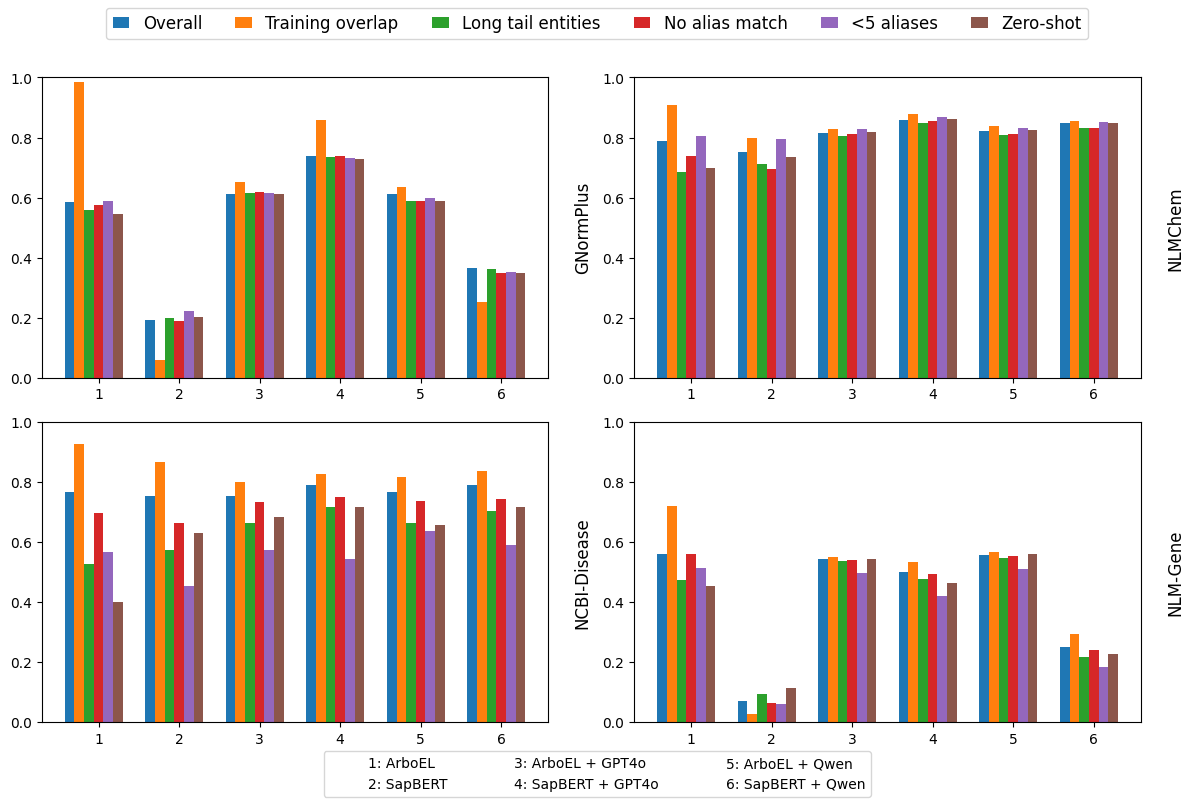

In [31]:
categories = ["ArboEL", "SapBERT", "ArboEL + GPT4o", "SapBERT + GPT4o", "ArboEL + Qwen", "SapBERT + Qwen"]
metrics = [
    "Overall",
    "Training overlap",  # This metric will be ignored with "#"
    "Long tail entities",
    "No alias match",
    "# Wrong match",
    "<5 aliases",
    "Zero-shot"
]

# Corresponding data: each column corresponds to the same position as in the metrics list
data_nlm_gene = np.array([
    [0.559, 0.721, 0.473, 0.560, 0.463, 0.513, 0.455],  # ArboEL
    [0.072, 0.029, 0.095, 0.063, 0.074, 0.061, 0.115],  # SapBERT
    [0.543, 0.551, 0.538, 0.541, 0.496, 0.497, 0.544],  # ArboEL + GPT4o
    [0.501, 0.534, 0.477, 0.494, 0.504, 0.419, 0.465],  # SapBERT + GPT4o
    [0.556, 0.567, 0.548, 0.553, 0.561, 0.509, 0.559],  # ArboEL + Qwen
    [0.251, 0.295, 0.217, 0.242, 0.204, 0.185, 0.227],  # SapBERT + Qwen
])

data_gnormplus = np.array([
    [0.585, 0.985, 0.558, 0.576, 0.675, 0.587, 0.546],  # ArboEL
    [0.191, 0.059, 0.200, 0.190, 0.119, 0.221, 0.201],  # SapBERT
    [0.611, 0.652, 0.615, 0.617, 0.620, 0.614, 0.613],  # ArboEL + GPT4o
    [0.738, 0.857, 0.735, 0.740, 0.793, 0.731, 0.729],  # SapBERT + GPT4o
    [0.611, 0.636, 0.587, 0.587, 0.617, 0.597, 0.588],  # ArboEL + Qwen
    [0.365, 0.252, 0.362, 0.348, 0.388, 0.352, 0.350],  # SapBERT + Qwen
])

data_ncbi_disease = np.array([
    [0.766, 0.927, 0.527, 0.697, 0.941, 0.568, 0.400],  # ArboEL
    [0.752, 0.867, 0.572, 0.664, 0.914, 0.452, 0.630],  # SapBERT
    [0.752, 0.799, 0.662, 0.734, 0.792, 0.572, 0.682],  # ArboEL + GPT4o
    [0.790, 0.827, 0.718, 0.750, 0.899, 0.542, 0.717],  # SapBERT + GPT4o
    [0.767, 0.815, 0.662, 0.738, 0.797, 0.636, 0.656],  # ArboEL + Qwen
    [0.791, 0.837, 0.703, 0.743, 0.892, 0.589, 0.717],  # SapBERT + Qwen
])

data_nlmchem = np.array([
    [0.787, 0.908, 0.684, 0.738, 0.256, 0.806, 0.697],  # ArboEL
    [0.752, 0.800, 0.711, 0.694, 0.178, 0.796, 0.734],  # SapBERT
    [0.815, 0.828, 0.805, 0.811, 0.394, 0.827, 0.818],  # ArboEL + GPT4o
    [0.859, 0.879, 0.847, 0.856, 0.212, 0.867, 0.862],  # SapBERT + GPT4o
    [0.821, 0.838, 0.807, 0.813, 0.300, 0.830, 0.826],  # ArboEL + Qwen 
    [0.849, 0.856, 0.831, 0.832, 0.185, 0.850, 0.847],  # SapBERT + Qwen 
])


# Filter metrics and data to ignore those that are commented (i.e., strings starting with "#")
active_indices = [i for i, metric in enumerate(metrics) if not metric.strip().startswith("#")]
active_metrics = [metrics[i] for i in active_indices]
filtered_data_gnormplus = data_gnormplus[:, active_indices]
filtered_data_nlmchem = data_nlmchem[:, active_indices]
filtered_data_ncbi_disease = data_ncbi_disease[:, active_indices]
filtered_data_nlm_gene = data_nlm_gene[:, active_indices]

x_numeric = np.arange(1, len(categories) + 1)
width = 0.12

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# 1) GNormPlus bars
for i, metric in enumerate(active_metrics):
    # Shift each bar group by i * width around x_numeric
    ax1.bar(x_numeric + i * width - width*(len(active_metrics)/2), 
            filtered_data_gnormplus[:, i], 
            width, label=metric)
ax1.text(1.05, 0.5, 'GNormPlus', transform=ax1.transAxes,
         rotation=90, fontsize=12, va='center')
ax1.set_xticks(x_numeric)
ax1.set_xticklabels(x_numeric)     # Just show numeric 1..6
ax1.set_ylim(0, 1)


# 2) NLMChem bars
for i, metric in enumerate(active_metrics):
    ax2.bar(x_numeric + i * width - width*(len(active_metrics)/2), 
            filtered_data_nlmchem[:, i], 
            width, label=metric)
ax2.text(1.05, 0.5, 'NLMChem', transform=ax2.transAxes,
         rotation=90, fontsize=12, va='center')
ax2.set_xticks(x_numeric)
ax2.set_xticklabels(x_numeric)
ax2.set_ylim(0, 1)

# 3) NCBI-Disease bars
for i, metric in enumerate(active_metrics):
    ax3.bar(x_numeric + i * width - width*(len(active_metrics)/2), 
            filtered_data_ncbi_disease[:, i], 
            width, label=metric)
ax3.text(1.05, 0.5, 'NCBI-Disease', transform=ax3.transAxes,
         rotation=90, fontsize=12, va='center')
ax3.set_xticks(x_numeric)
ax3.set_xticklabels(x_numeric)
ax3.set_ylim(0, 1)

# 4) NLM-Gene bars
for i, metric in enumerate(active_metrics):
    ax4.bar(x_numeric + i * width - width*(len(active_metrics)/2), 
            filtered_data_nlm_gene[:, i], 
            width, label=metric)
ax4.text(1.05, 0.5, 'NLM-Gene', transform=ax4.transAxes,
         rotation=90, fontsize=12, va='center')
ax4.set_xticks(x_numeric)
ax4.set_xticklabels(x_numeric)
ax4.set_ylim(0, 1)

# Legend for the metrics (the different bar colors)
handles_m, labels_m = ax4.get_legend_handles_labels()  # or ax1, they’re the same
fig.legend(handles_m, labels_m, loc='upper center', ncol=len(active_metrics),
           fontsize=12, handlelength=1)

# "Legend" for the categories (1 = ArboEL, etc.)
# We can do a second legend or a text box. For a second legend:
cat_labels = [f"{i+1}: {cat}" for i, cat in enumerate(categories)]
# Create invisible patches just to carry the text labels
cat_patches = [mpatches.Patch(color='none', label=lbl) for lbl in cat_labels]
fig.legend(cat_patches, cat_labels, loc='lower center', ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()
